<a href="https://colab.research.google.com/github/Idguerrero333/NOTEBOOKPYTHONINTERACTIVE/blob/main/precios_de_inmuebles_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Precificación inmobiliaria**

**Objetivo**: Estimar los precios de los inmuebles.
 * Identificar los aspectos que tienen más influencia en la precificación de los inmuebles.
 * Entender cuál de todos estos aspectos es el más relevante.
 * Precificar un inmueble nuevo.

Base de datos simplificada e inspirada en [House Prices](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)



![](https://i.imgur.com/A8X79yq.jpeg)


area_primer_piso: Se refiere al área del primer piso de la propiedad, medida en metros cuadrados.
existe_segundo_piso: Esta variable es binaria, indicando si la propiedad tiene o no un segundo piso. Puede ser representada como 1 para "sí" y 0 para "no".
area_segundo_piso: Si la propiedad tiene un segundo piso, esta variable representa el área total del segundo piso, medida en metros cuadrados.
cantidad_baños: Indica el número total de baños en la propiedad.
capacidad_coches_garaje: Esta variable indica la capacidad del garaje de la propiedad, es decir, el número máximo de coches que pueden estacionarse en el garaje.
calidad_de_la_cocina_Excelente: Esta es una variable categórica que evalúa la calidad de la cocina en la propiedad. En este caso, se asume que si la cocina es considerada "Excelente" se representa por 1, y de lo contrario, por 0.
precio_de_venta: Este es el precio de venta de la propiedad en reales. Es la variable objetivo que se intenta predecir utilizando los otros atributos de la propiedad.

# 1. Ajustando una recta

## Conociendo los datos

In [3]:
#Leyendo los datos
import pandas as pd
datos = pd.read_csv('/content/precios_casas.csv')
datos.head(2)

,Id,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente,precio_de_venta
0,1,79.5224,1,79.3366,2,548,0,1027905.0
1,2,117.2398,0,0.0000,2,460,0,894795.0


In [4]:
#Cuáles factores fueron colectados
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Id                           1438 non-null   int64  
 1   area_primer_piso             1438 non-null   float64
 2   tiene_segundo_piso           1438 non-null   int64  
 3   area_segundo_piso            1438 non-null   float64
 4   cantidad_banos               1438 non-null   int64  
 5   capacidad_carros_garage      1438 non-null   int64  
 6   calidad_de_cocina_excelente  1438 non-null   int64  
 7   precio_de_venta              1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [5]:
datos = datos.drop(columns='Id')#eliminando columna
datos.columns

Index(['area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente', 'precio_de_venta'],
      dtype='object')

## Correlación

**¿Cuáles factores están relacionados con el precio de la casa? ¿Cómo es esa relación?**

El coeficiente de correlación de Pearson nos permite medir la relación lineal entre variables, ofreciendo una escala que varía de -1 a 1, la cual interpretamos según su intensidad y dirección:

* **-1**: correlación negativa perfecta: a medida que una variable aumenta, la otra disminuye.  
* **0**: no hay relación lineal entre las variables.  
* **1**: correlación positiva perfecta: a medida que una variable aumenta, la otra también aumenta.  



In [6]:
# Correlación
corr = datos.corr()

In [8]:
corr['precio_de_venta']

,precio_de_venta
area_primer_piso,0.616557
tiene_segundo_piso,0.138541
area_segundo_piso,0.305311
cantidad_banos,0.563132
capacidad_carros_garage,0.640214
calidad_de_cocina_excelente,0.496223
precio_de_venta,1.000000


In [ ]:
# Actividad
# Cuáles factores están más correlacionados?


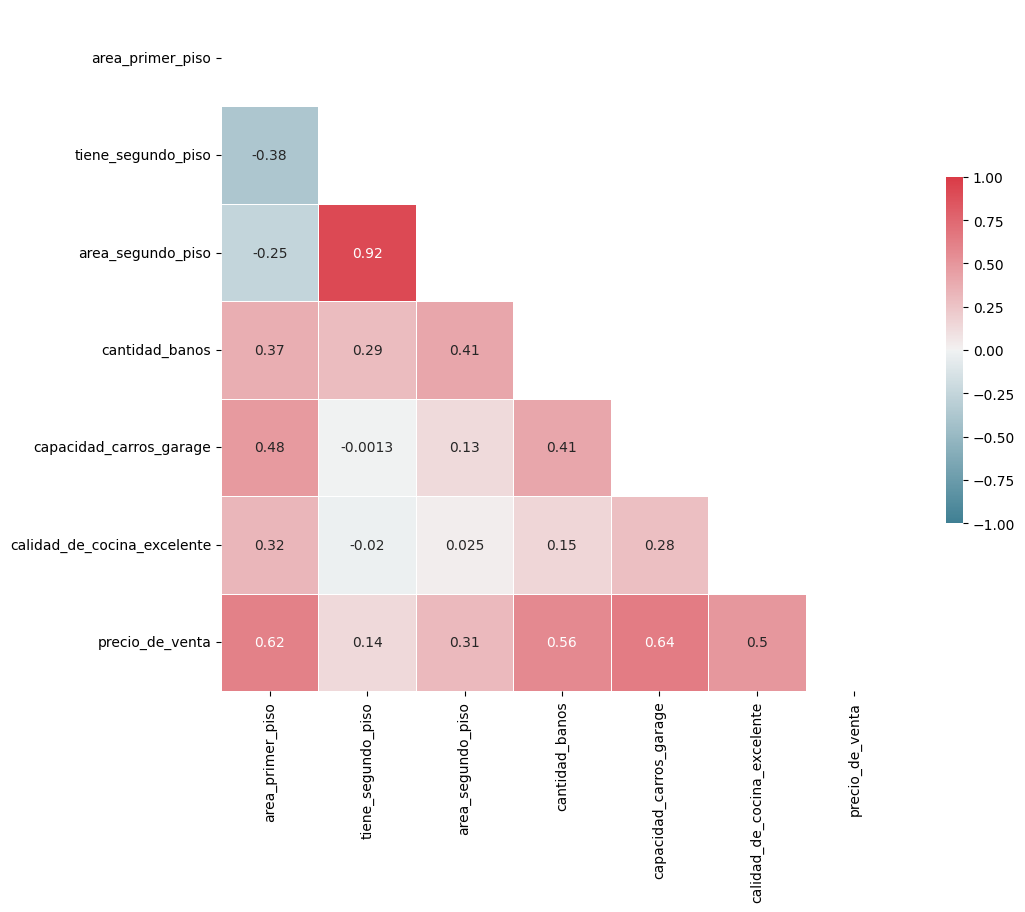

In [10]:
# Actividad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ¿Qué factores están más correlacionados?

# Generar una máscara para el triángulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar la figura de matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Generar el mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Mostrar el mapa de calor (heatmap)
plt.show()

Intensidad: se refiere a la fuerza de la relación entre las variables medidas. Puede variar de -1 a +1, donde -1 indica una correlación perfectamente negativa, +1 indica una correlación perfectamente positiva y 0 indica ausencia de correlación lineal.
Dirección: se refiere a la naturaleza de la relación entre las variables medidas. Una correlación positiva indica que las variables aumentan o disminuyen juntas, mientras que una correlación negativa indica que una variable aumenta mientras la otra disminuye, o viceversa.

El coeficiente de correlación lineal entre el área del primer piso y el precio de venta es de 0.62, indicando una correlación positiva moderadamente fuerte (intensidad). En general, a medida que el área del primer piso de una casa aumenta, el precio de venta también tiende a aumentar (dirección).

La correlación entre la capacidad de coches en la garaje y el área del primer piso es 0.48 moderadamente positiva, indicando que, en general, a medida que la capacidad de coches en la garaje aumenta, el área del primer piso de la casa tiende a aumentar también.
Entre garaje para coches y cantidad de baños es moderadamente positiva (0.409281), indicando que, en general, a medida que la capacidad de la garaje aumenta, el número de baños también tiende a aumentar. Esto sugiere una posible asociación entre el espacio para estacionamiento de vehículos y el tamaño de la residencia.
Cuando miramos la correlación entre el área del primer piso y el área del segundo piso, verificamos que es débil y negativa (-0.25). Esto sugiere que, en general, cuando el área del primer piso de una casa aumenta, el área del segundo piso tiende a disminuir un poco, y viceversa. Esta relación indica una posible compensación entre las áreas de los dos pisos, pero no es una relación muy fuerte y puede variar entre diferentes propiedades.

## Relacionando variables

In [11]:
# importando los paquetes para la visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

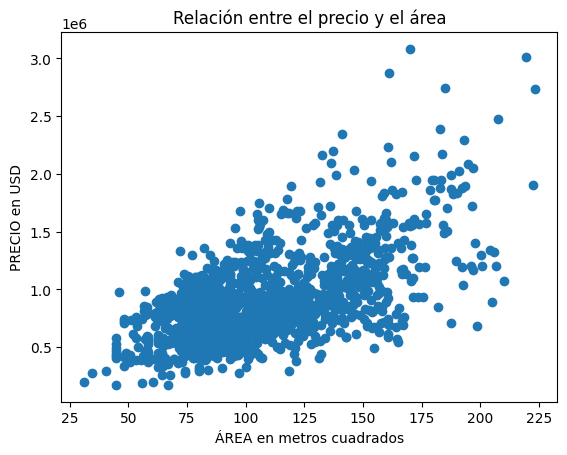

In [13]:
# Cómo se relacionan el área construída y el precio del inmueble?
plt.scatter(datos['area_primer_piso'],datos['precio_de_venta'])
plt.title('Relación entre el precio y el área')
plt.xlabel('ÁREA en metros cuadrados')
plt.ylabel('PRECIO en USD')
plt.show()

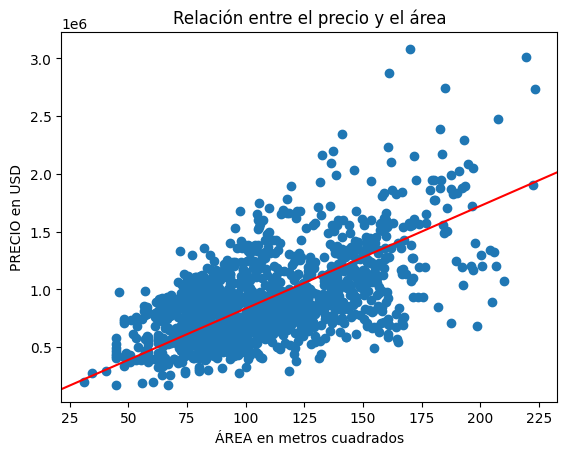

In [16]:
# Aparentemente mientras mayor es el área del primer piso, mayor es el precio de la casa.
# E si quisieramos trazar una línea que nos permita describir este comportamiento?
plt.scatter(datos['area_primer_piso'],datos['precio_de_venta'])
plt.axline(xy1=(40,300000),xy2=(175,1500000),color='red')
plt.title('Relación entre el precio y el área')
plt.xlabel('ÁREA en metros cuadrados')
plt.ylabel('PRECIO en USD')
plt.show()

## Mejor recta

In [17]:
# Cuál es la recta que mejor se ajusta a esta relación con minimos de cuadrados ordinarios y metodo OLS
px.scatter(datos,x='area_primer_piso',y='precio_de_venta',trendline_color_override='red', trendline='ols')

# 2. Explicando la recta
Ajustamos una recta entre los $m^2$ del primer piso y el precio de la casa. Queremos explicar el precio de la casa a partir de su tamaño, por eso decimos que:

* Variable explicativa/independiente: Área del primer piso  
* Variable de respuesta/dependiente: Precio de la casa  

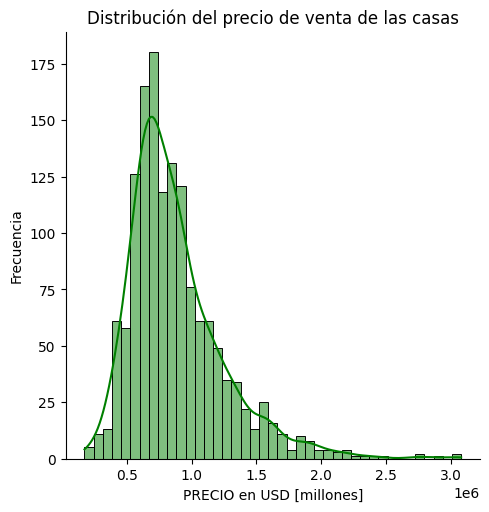

In [19]:
#Quién es nuestra variable de respuesta?
sns.displot(datos['precio_de_venta'],kde=True,color='green')
plt.title('Distribución del precio de venta de las casas')
plt.xlabel('PRECIO en USD [millones]')
plt.ylabel('Frecuencia')
plt.show()

### Separando datos para entrenamiento y para prueba

El conjunto de **entrenamiento** se utiliza para ajustar el modelo, mientras que el conjunto de **prueba** se usa para evaluar su desempeño al predecir precios de viviendas no vistos durante el entrenamiento, lo que ayuda a la generalización del modelo.

In [20]:
# import train_test_split
from sklearn.model_selection import train_test_split

y = datos['precio_de_venta']
X = datos.drop(columns='precio_de_venta')

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=230) # garantizar la reproductividad de la segregacion de los datos

In [21]:
#Datos de entrenamiento para usar la fórmula
df_train = pd.DataFrame(X_train)
df_train['precio_de_venta'] = y_train
df_train.head(2)


,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente,precio_de_venta
1303,65.7732,0,0.0000,1,0,0,406725.0
326,55.3684,1,55.3684,1,189,0,384540.0


In [22]:
# import ols
from statsmodels.formula.api import ols

In [23]:
# ajustando el primer modelo precio de venta con respecto a area primer piso
modelo_0 = ols('precio_de_venta ~ area_primer_piso',data=df_train).fit()
#

Dividir el conjunto de datos en conjuntos de entrenamiento y prueba es una práctica esencial en machine learning para evaluar la capacidad de generalización del modelo. El conjunto de entrenamiento se usa para entrenar el modelo, mientras que el conjunto de prueba se mantiene separado y se usa para evaluar el desempeño del modelo en datos no vistos, simulando cómo se comportaría el modelo al ser aplicado en situaciones reales.

## Analizando los coeficientes

(intensidad, dirección y significancia)




In [24]:
# visualizando los parámetros
modelo_0.params

,0
Intercept,152909.288334
area_primer_piso,6793.641641


In [25]:
# El resumen del modelo
print(modelo_0.summary())

                            OLS Regression Results                            
Dep. Variable:        precio_de_venta   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          2.22e-105
Time:                        02:18:10   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1.529e+05   3.07e+04  

- El **punto de intercepción** es el valor esperado del precio de la casa cuando todas las demás variables son cero. En este caso, cuando todas las demás variables, incluida el área del primer piso, son cero, el precio esperado de la casa es de $145.196,40. No siempre se tiene una interpretación práctica para este número.

- El **efecto individual** del área es de \$6.833,97. Esto indica que por cada metro cuadrado adicional al área del primer piso, se espera que el precio de la casa aumente en promedio \$6.833,97.

<img src="https://i.ibb.co/CJwfMgW/coeficientes.png" alt="coeficientes" border="0">


La regresión lineal fue la metodología que ajustó la mejor línea que representa linealmente la interacción entre X e Y; en nuestro caso, el tamaño del área del primer piso y el precio de venta de la casa.

Vale la pena repasar cada componente de la regresión lineal:

Función
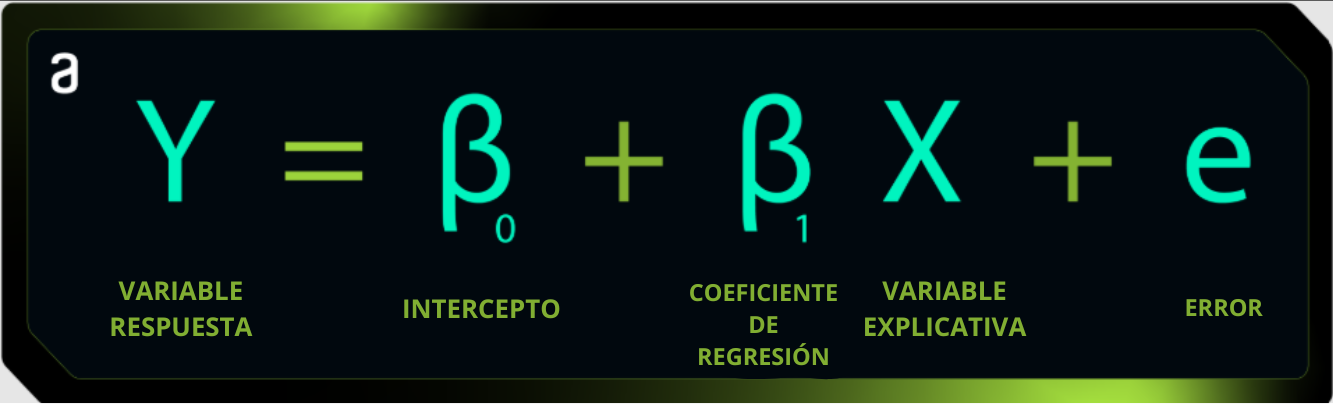

Variable Respuesta (Y): También llamada variable dependiente, es aquella que estamos tratando de predecir.
Intercepto (β₀): El punto donde la línea de regresión intercepta el eje vertical (Y), es decir, el valor de Y cuando X es igual a 0.
Variable Explicativa (X): También llamada variable independiente, es el factor que usamos para predecir y explicar la variable respuesta.
Coeficientes de Regresión (β₁): Impacto de cada variable explicativa X en la variable respuesta, es el efecto de X en Y.
Error Residual (e): Diferencia entre los valores reales y previstos de la variable respuesta.
Coeficientes
La relación lineal entre las variables X e Y se representa gráficamente por una línea. Este proceso de encontrar la línea ideal implica minimizar la distancia entre los puntos reales y la propia línea.

El ajuste de la línea de regresión lineal se simplifica mediante el método de los mínimos cuadrados. Este método tiene como objetivo encontrar la línea que mejor se ajusta a los datos observados, minimizando la suma de los cuadrados de las diferencias entre los valores reales y los valores previstos por la línea y calculando los coeficientes del modelo.

## Explicabilidad del modelo

**¿En qué medida la variación del área explica los diversos precios de las casas?**  

En este caso, recurrimos a la métrica R², el coeficiente de determinación. El R² varía de 0 a 1, donde 1 indica un ajuste perfecto del modelo a los datos, es decir, todas las variaciones en la variable dependiente son explicadas por las variables independientes en el modelo. Por otro lado, un R² de 0 indica que el modelo no explica ninguna variabilidad en la variable dependiente.

In [33]:
# observando el R²
round(modelo_0.rsquared,2)

np.float64(0.38)

El coeficiente de determinación, frecuentemente llamado R², es una medida estadística que indica cuánto de la variabilidad de la variable dependiente (respuesta) es explicada por el modelo de regresión lineal.

Interpretando el R²
Varía de 0 a 1, un valor cercano a 1 indica que el modelo se ajusta bien a los datos, explicando la mayor parte de la variación en la variable dependiente/respuesta. Por otro lado, un valor cercano a 0 indica que el modelo no puede explicar mucha variación en la variable dependiente/respuesta.

Usando en la prueba
Además, el R² puede ser utilizado para comparar el rendimiento del modelo en diferentes conjuntos de datos, como entrenamiento y prueba. Esto ayuda a identificar problemas de sobreajuste (overfitting) o subajuste (underfitting). Idealmente, deseamos que el R² sea consistente entre los conjuntos de entrenamiento y prueba, indicando una buena capacidad de generalización del modelo para nuevos datos.

Fórmula
Una de las fórmulas del R² puede ser representada por la razón entre la variación explicada y la variación total. Por eso decimos que cuanto más cerca de 1, mejor es la adecuación del modelo, ya que la variación explicada será más cercana a la variación total en esta razón.

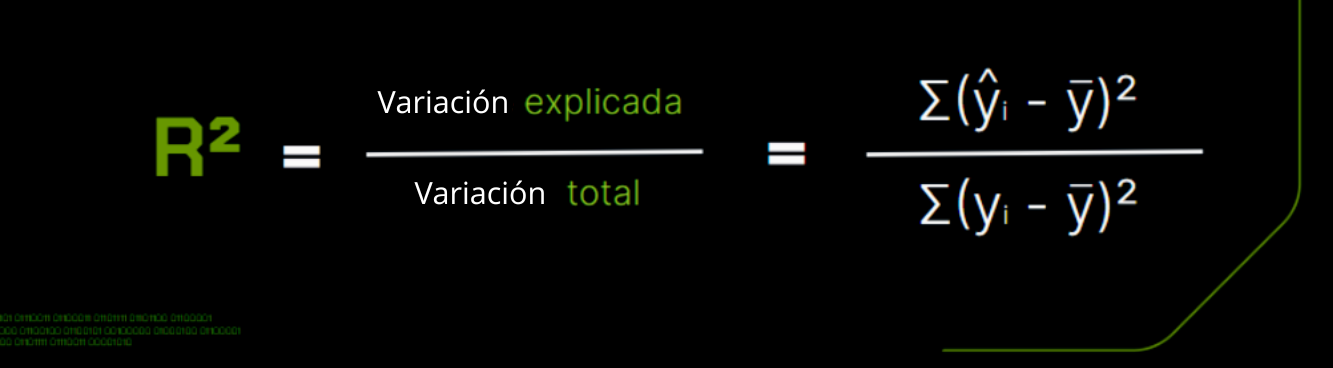

## Entendiendo el resíduo

In [27]:
# Quiénes son los residuos?
modelo_0.resid

,0
1303,-193023.838744
326,-144522.356193
386,399612.747641
615,-68449.596607
236,166010.592859
...,...
777,465872.680999
271,-497642.319788
723,461150.204718
560,-540482.733402


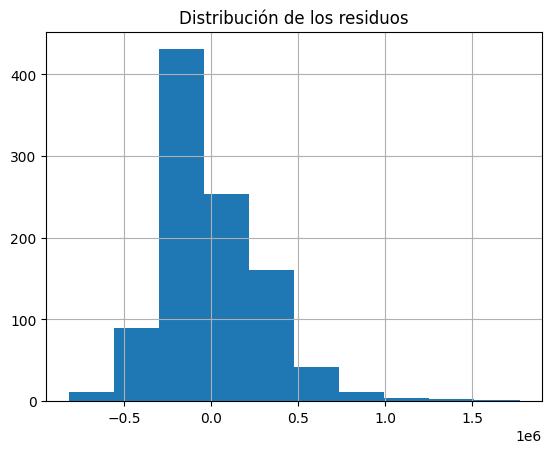

In [29]:
# Cómo están distribuidos
modelo_0.resid.hist()
plt.title('Distribución de los residuos')
plt.show()

<img src="https://i.ibb.co/zGTB35V/residuos.png" alt="residuos" border="0">

## Obteniendo el R² de la previsión

In [30]:
# definiendo la 'Y' prevista
y_predict= modelo_0.predict(X_test)

In [35]:
# importando el r2_score
from sklearn.metrics import r2_score


In [36]:
# mostrando el resultado de r²
print(f'El coeficiente de determinacion R² para el modelo con los datos de prueba es:{round(r2_score(y_test,y_predict),2)}')

El coeficiente de determinacion R² para el modelo con los datos de prueba es:0.39


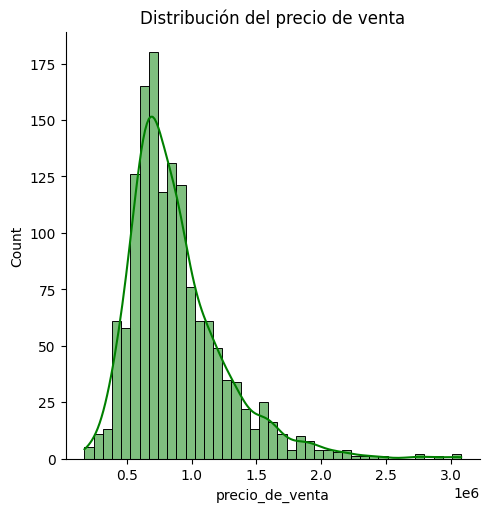

In [38]:
sns.displot(datos['precio_de_venta'], kde=True, color='green')
plt.title('Distribución del precio de venta')
plt.show()

# 3. Añadiendo otras características

El modelo con un solo factor nos mostró un R² de 0.38, es decir, aproximadamente el 38% de la variación observada en los precios de las casas puede explicarse por la variación en el área.  
Esto indica que aún existe una cantidad significativa de variación que no está siendo capturada por este modelo específico. Analizaremos otros factores para explicar el precio de las casas.

## Analizando los factores

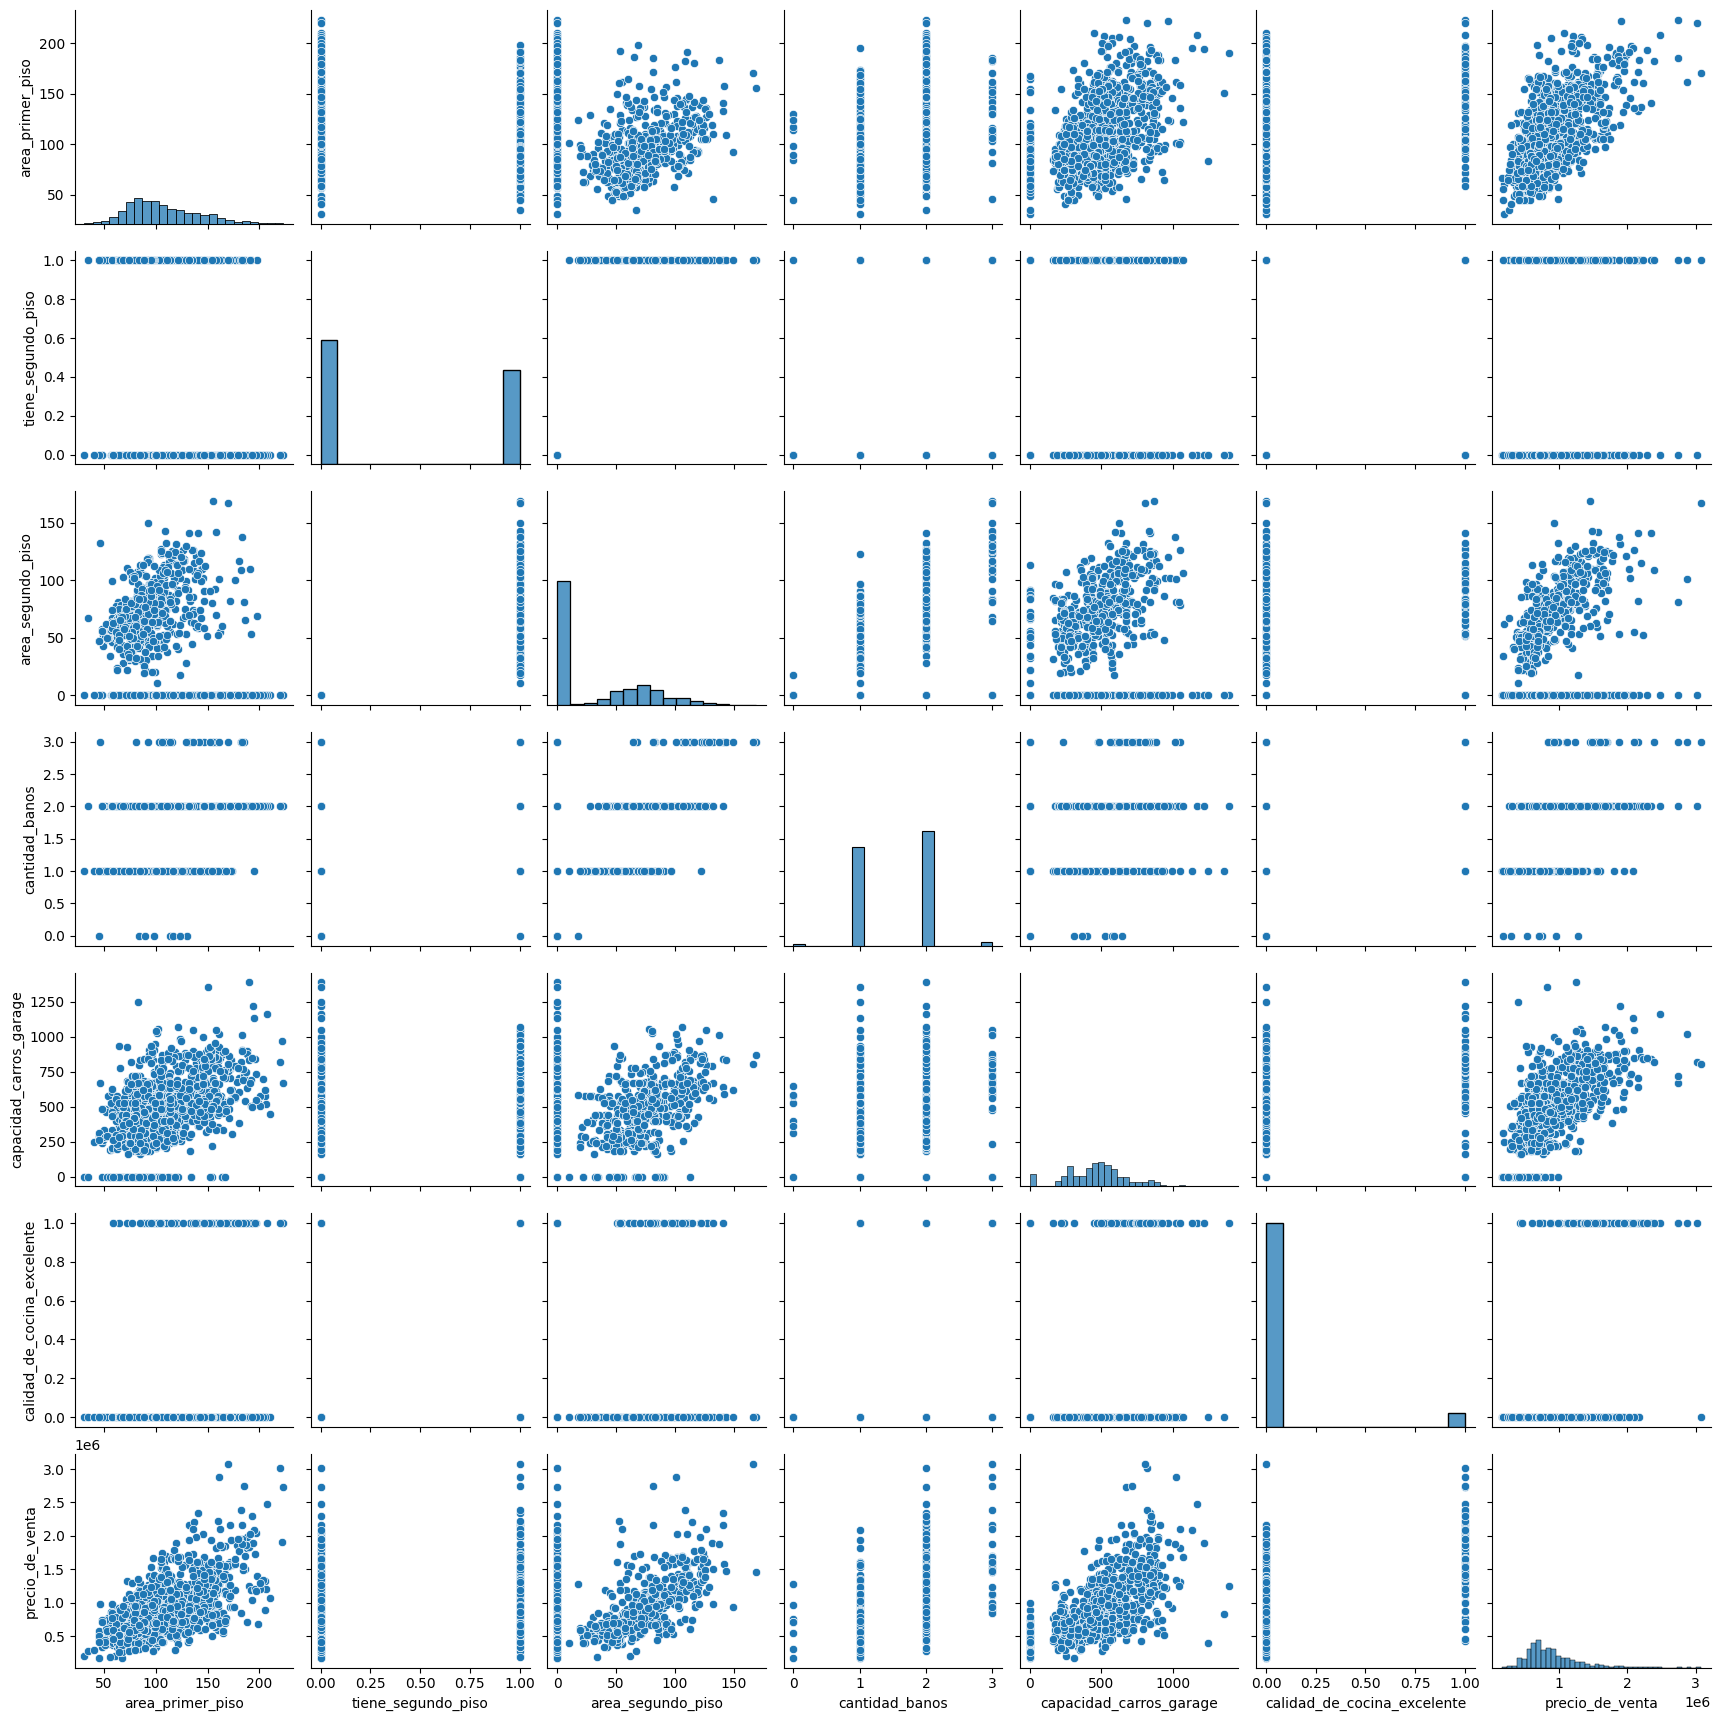

In [39]:
# cuáles otras características podrían explicar el precio de los inmuebles?
sns.pairplot(datos)

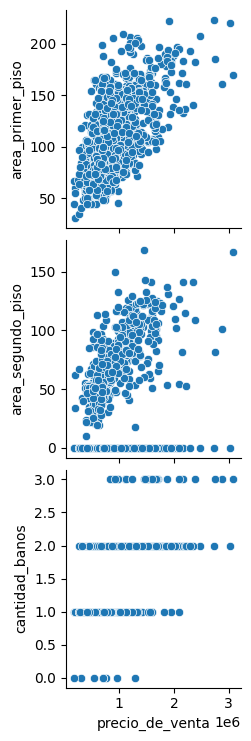

In [42]:
#Vamos a analizar solamente y_vars='precio_de_venta'
sns.pairplot(datos,y_vars=['area_primer_piso','area_segundo_piso','cantidad_banos'],x_vars='precio_de_venta')

## Añadiendo factores al modelo

In [43]:
# importando la api de statsmodels
import statsmodels.api as sm

In [44]:
# Añadiendo una constante
X_train = sm.add_constant(X_train)
X_train.head()

,const,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente
1303,1.0,65.7732,0,0.0000,1,0,0
326,1.0,55.3684,1,55.3684,1,189,0
386,1.0,74.6916,1,107.4853,2,560,0
615,1.0,103.6764,0,0.0000,1,440,0
236,1.0,94.2006,1,67.8170,2,457,0


In [45]:
X_train.columns

Index(['const', 'area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente'],
      dtype='object')

In [47]:
# Creando el modelo de regresión (con todas las variables): saturado
modelo_1 = sm.OLS(y_train, X_train[['const', 'area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
                                  'cantidad_banos', 'capacidad_carros_garage',
                                  'calidad_de_cocina_excelente']]).fit()

In [48]:
# Modelo sin el área del segundo piso
modelo_2 = sm.OLS(y_train, X_train[['const', 'area_primer_piso', 'tiene_segundo_piso',
                                    'cantidad_banos', 'capacidad_carros_garage',
                                    'calidad_de_cocina_excelente']]).fit()

In [49]:
# Modelo sin la información del garage
# Modelo sin el área del segundo piso
modelo_3 = sm.OLS(y_train, X_train[['const', 'area_primer_piso', 'tiene_segundo_piso',
                                    'cantidad_banos','calidad_de_cocina_excelente']]).fit()

In [54]:
# Resumen del modelos
modelos = [modelo_0, modelo_1, modelo_2, modelo_3]
for i,j in enumerate(modelos):
    print(f'*******************************************************************************************\n************ El modelo {i} tiene el siguiente resumen: *********************************************** \n*******************************************************************************************')
    print(j.summary(),'\n\n')
#

*******************************************************************************************
************ El modelo 0 tiene el siguiente resumen: *********************************************** 
*******************************************************************************************
                            OLS Regression Results                            
Dep. Variable:        precio_de_venta   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          2.22e-105
Time:                        03:05:05   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Cov

In [55]:
for i,j in enumerate(modelos):
    print(f'El coeficiente de la determinacion R² para el modelo {i} es: {round(j.rsquared,2)}')

El coeficiente de la determinacion R² para el modelo 0 es: 0.38
El coeficiente de la determinacion R² para el modelo 1 es: 0.74
El coeficiente de la determinacion R² para el modelo 2 es: 0.71
El coeficiente de la determinacion R² para el modelo 3 es: 0.65


En la clase sobre comparación de modelos de regresión lineal, exploramos cómo evaluar y seleccionar el modelo más adecuado utilizando el R² y otros criterios. Además de la selección manual que discutimos, existen métodos automáticos de selección de variables que pueden ser extremadamente útiles en situaciones donde el número de variables explicativas es grande. Estos métodos, como stepwise, backward y forward selection, siguen criterios predefinidos para agregar o eliminar variables del modelo de forma iterativa. Explora a continuación los métodos automáticos de selección de variables, que buscan equilibrar la complejidad del modelo y su capacidad explicativa.

El método de forward selection comienza con un modelo sin variables explicativas y agrega una a una, eligiendo en cada paso la variable que más mejora el modelo de acuerdo con un criterio estadístico específico, como el menor valor de p-valor o el mayor aumento en el R² ajustado.
El backward selection inicia con todas las variables posibles en el modelo y, de manera iterativa, elimina la variable que menos contribuye al modelo, nuevamente basándose en criterios como el p-valor o el impacto en el R² ajustado.
El stepwise selection es una combinación de los dos métodos anteriores, donde las variables pueden ser agregadas o eliminadas en cada paso, dependiendo de su contribución a la mejora del modelo.
Estos métodos de selección automática son herramientas poderosas que ayudan en la identificación del modelo más parsimonioso, es decir, aquel que puede explicar los datos de manera eficiente sin ser excesivamente complejo. Sin embargo, es crucial que el científico de datos comprenda y supervise el proceso, ya que la elección automática puede, a veces, introducir sesgo o sobreajuste, especialmente si el criterio de selección no es bien elegido o si el modelo no es validado adecuadamente con datos nuevos o de prueba.

## Comparando los modelos
Cuál es el modelo?


In [56]:
# Cuántos parámetros tiene el modelo?
modelo_3.params

,0
const,-129979.678094
area_primer_piso,6119.653184
tiene_segundo_piso,221306.959705
cantidad_banos,149036.289458
calidad_de_cocina_excelente,444391.228573


En esta clase, aprendiste a:
Utilizar el pairplot de Seaborn para visualizar relaciones entre múltiples variables e identificar cuáles pueden influir en el precio de venta de las casas.
Agregar múltiples variables explicativas al modelo de regresión lineal para mejorar la precisión de las predicciones de precios.
Comparar diferentes modelos de regresión lineal utilizando el R² y el R² ajustado, además de analizar la multicolinealidad y otros factores.
Descubrir cómo interpretar los coeficientes del modelo de regresión lineal para entender el impacto de cada variable en el precio de las casas.
Entender la importancia de elegir el modelo más adecuado para la predicción de precios, considerando la simplicidad, la precisión y la interpretabilidad.

# 4. Precificando las casas

## Obteniendo el R² de la previsión

In [57]:
# Añadiendo una constante en X_test
X_test = sm.add_constant(X_test)
X_test.head(2)

,const,area_primer_piso,tiene_segundo_piso,area_segundo_piso,cantidad_banos,capacidad_carros_garage,calidad_de_cocina_excelente
997,1.0,94.9438,0,0.0000,1,280,0
805,1.0,74.1342,1,78.2218,2,595,0


In [59]:
# Previsión con el modelo 3
prevision_3 = modelo_3.predict(X_test[['const', 'area_primer_piso', 'tiene_segundo_piso',
                                    'cantidad_banos','calidad_de_cocina_excelente']])

In [61]:
# Cuál es el r² de la previsión?
print(f'El coeficiente R² de la base de prevision es: {modelo_3.rsquared.round(2)}')

El coeficiente R² de la base de prevision es: 0.65


In [62]:
# Cuál es el R² del entrenamiento?
print(f'El coeficiente R² con respecto a la base de entrenamiento es: {round(r2_score(y_test,prevision_3),2)}')

El coeficiente R² con respecto a la base de entrenamiento es: 0.64


Comparar el R² de entrenamiento y prueba ayuda a identificar si el modelo está sobreajustado a los datos de entrenamiento (overfitting), lo que perjudica su capacidad de generalización. Si hay una diferencia muy grande entre los valores de entrenamiento y prueba, puede indicar que el modelo está siendo influenciado por patrones específicos de los datos de entrenamiento que no son generalizables a los datos de prueba.

## Precificando una casa

<img src="https://i.ibb.co/SvG4V4j/costo.png" alt="costo" border="0">

In [63]:
datos.columns

Index(['area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
       'cantidad_banos', 'capacidad_carros_garage',
       'calidad_de_cocina_excelente', 'precio_de_venta'],
      dtype='object')

In [68]:
#Nuevo inmueble
nuevo_inmueble = pd.DataFrame({
    'const':[1],
    'area_primer_piso':[120],
    'tiene_segundo_piso':[1],
    'cantidad_banos':[2],
    'calidad_de_cocina_excelente':[0]
})

In [69]:
# Cuál es el precio del inmueble de acuerdo con el modelo 0?
modelo_0.predict(nuevo_inmueble['area_primer_piso']).round(2)

,0
0,968146.29


In [70]:
#Cuál es el precio del inmueble de acuerdo con el modelo 3?
modelo_3.predict(nuevo_inmueble).round(2)

,0
0,1123758.24


In [71]:
modelo_3.params

,0
const,-129979.678094
area_primer_piso,6119.653184
tiene_segundo_piso,221306.959705
cantidad_banos,149036.289458
calidad_de_cocina_excelente,444391.228573


## Precificando varias casas

<img src="https://i.imgur.com/i0skFlB.jpeg" width="600"/>

In [74]:
# Leyendo varias casas?
nuevas_casas = pd.read_csv('/content/nuevas_casas.csv', sep=';')
nuevas_casas.head(2)

,Casa,area_primer_piso,tiene_segundo_piso,cantidad_banos,calidad_de_cocina_excelente
0,1,150,1,2,1
1,2,180,0,3,1


In [75]:
nuevas_casas.drop(columns='Casa', inplace=True)

In [78]:
# Añadiendo una constante
nuevas_casas = sm.add_constant(nuevas_casas)
nuevas_casas.head(2)

,const,area_primer_piso,tiene_segundo_piso,cantidad_banos,calidad_de_cocina_excelente
0,1.0,150,1,2,1
1,1.0,180,0,3,1


In [79]:
# Cuál es el precio de estas nuevas casas?
# precio_casas = pd.DataFrame()
# precio_casas = pd.DataFrame()
nuevas_casas['Precio de Venta'] = modelo_3.predict(nuevas_casas).round(2)
nuevas_casas

,const,area_primer_piso,tiene_segundo_piso,cantidad_banos,calidad_de_cocina_excelente,Precio de Venta
0,1.0,150,1,2,1,1751739.07
1,1.0,180,0,3,1,1863057.99
2,1.0,120,1,2,1,1568149.47
3,1.0,200,1,3,1,2206758.02
4,1.0,160,0,2,1,1591628.64
5,1.0,140,1,2,0,1246151.31
6,1.0,170,0,3,0,1357470.23
7,1.0,190,1,2,0,1552133.97
8,1.0,130,0,2,0,963647.81
9,1.0,180,1,3,0,1639973.72


Recibiste una solicitud para estimar el precio de una casa con las siguientes características:

1 baño
Área 98m²
No tiene segundo piso
Calidad de la cocina excelente

In [81]:
#Nuevo inmueble
nuevo_inmueble = pd.DataFrame({
    'const':[1],
    'area_primer_piso':[98],
    'tiene_segundo_piso':[0],
    'cantidad_banos':[1],
    'calidad_de_cocina_excelente':[1]
})


In [82]:
modelo_0.predict(nuevo_inmueble['area_primer_piso'])

,0
0,818686.169194


In [83]:
modelo_3.predict(nuevo_inmueble).round(2)

,0
0,1063173.85


Al desarrollar modelos de regresión con Statsmodels, es común querer guardar estos modelos para uso futuro, ya sea para implementación en producción, compartir con otros miembros del equipo o simplemente para respaldo. Una manera conveniente de hacer esto en Python es usando la biblioteca pickle, que permite serializar objetos de Python en archivos y deserializarlos de vuelta a objetos de Python. Esta biblioteca no necesita ser instalada, ya que viene por defecto en Python.

Vamos a explorar cómo guardar un modelo de regresión lineal de Statsmodels con la biblioteca pickle y luego cómo leer el archivo.

Cómo guardar el Modelo con Pickle
Después de entrenar el modelo, podemos guardarlo en un archivo usando la biblioteca pickle. Para ello, es necesario importar la biblioteca y luego podemos usar la función pickle.dump(), indicando el modelo y el archivo como parámetros.


```
import pickle

# Nombre del archivo donde se guardará el modelo
nombre_archivo = 'modelo_regresion_lineal.pkl'

# Guardar el modelo en un archivo usando pickle
with open(nombre_archivo, 'wb') as archivo:
    pickle.dump(modelo, archivo)
```
Cargar el Modelo de vuelta con Pickle
Después de guardar el modelo, podemos cargarlo de vuelta para uso posterior. Para hacer esto, simplemente usamos el método pickle.load() utilizando el archivo como parámetro de la función.

```
# Cargar el modelo de vuelta del archivo
with open(nombre_archivo, 'rb') as archivo:
    modelo_cargado = pickle.load(archivo)
```




En esta clase, aprendiste a:
Obtener la métrica R² del modelo a partir de datos de prueba;
Entender la importancia de la comparación de métricas de entrenamiento y prueba para verificar la generalización del modelo;
Utilizar el método predict para realizar la predicción de nuevos valores a partir de un modelo de regresión;
Guardar un modelo de machine learning utilizando la biblioteca pickle;
Leer archivos pickle para obtener el modelo en su estado original.

# 5. Investigando el modelo





## Multicolinearidad

Cuando dos o más cosas que estás intentando estudiar son tan parecidas que es difícil determinar cuánto está influyendo cada una de ellas en el resultado.

In [84]:
# importar el VIF de statsmodel
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [85]:
explicativas_1 = ['const', 'area_primer_piso', 'tiene_segundo_piso', 'area_segundo_piso',
                  'cantidad_banos', 'capacidad_carros_garage',
                  'calidad_de_cocina_excelente']
explicativas_2 = ['const', 'area_primer_piso', 'tiene_segundo_piso',
                  'cantidad_banos', 'capacidad_carros_garage',
                  'calidad_de_cocina_excelente']
explicativas_3 = ['const', 'area_primer_piso', 'tiene_segundo_piso',
                  'cantidad_banos','calidad_de_cocina_excelente']


In [86]:
# VIF 1
vif_1 = pd.DataFrame()
vif_1['Variables'] = explicativas_1
vif_1['vif'] = [vif(X_train[explicativas_1],i) for i in range(len(explicativas_1))]
vif_1

,Variables,vif
0,const,20.230833
1,area_primer_piso,2.193680
2,tiene_segundo_piso,7.455059
3,area_segundo_piso,7.589396
4,cantidad_banos,1.720795
5,capacidad_carros_garage,1.570078
6,calidad_de_cocina_excelente,1.182606


In [87]:
# VIF 3
vif_3 = pd.DataFrame()
vif_3['Variables'] = explicativas_3
vif_3['vif'] = [vif(X_train[explicativas_3],i) for i in range(len(explicativas_3))]
vif_3

,Variables,vif
0,const,18.773457
1,area_primer_piso,1.919046
2,tiene_segundo_piso,1.644067
3,cantidad_banos,1.539255
4,calidad_de_cocina_excelente,1.151795


## Análisis de los residuos

Residuos: la discrepancia entre los valores reales y los valores que el modelo predice para los mismos puntos de datos.

In [88]:
#Prevision de los valores de entrenamiento X_train[explicativas_3]
y_previsto_train = modelo_3.predict(X_train[explicativas_3])

In [89]:
#Generando un scatter plot entre y_previsto e y_train
fig = px.scatter(x=y_previsto_train, y=y_train, title='Valor Previsto vs Real',
                 labels={'x':'Valor Previsto', 'y':'Valor Real'})
fig.show()

In [91]:
# Residuos
residuos = modelo_3.resid
fig = px.scatter(x=y_previsto_train, y=residuos, title='Valor Previsto vs Residuos',
                 labels={'x':'Valor Previsto', 'y':'Valor Residuos'})
fig.show()

<img src="https://i.ibb.co/9bmySbm/heterocedasticidad.png" alt="heterocedasticidad" border="0">

Cuando nos sumergimos en el universo del análisis de datos, un concepto fundamental que encontramos con frecuencia es la regresión lineal. Esta técnica nos permite entender relaciones y prever tendencias basándonos en datos existentes. Sin embargo, al aplicar la regresión lineal, es crucial estar atentos a la heterocedasticidad, una característica que puede afectar significativamente la interpretación de los resultados.

¿Qué es la Heterocedasticidad?
La heterocedasticidad es un término utilizado en estadística para describir una situación en la que la varianza de los errores (o residuos) de un modelo de regresión no es constante a lo largo del rango de valores previstos. En términos simples, si la dispersión de los residuos varía en diferentes niveles del predictor, estamos ante la heterocedasticidad. Esto es un problema porque la mayoría de los métodos de regresión lineal asumen homocedasticidad, es decir, que los residuos tienen varianza constante en todos los niveles de los predictores.

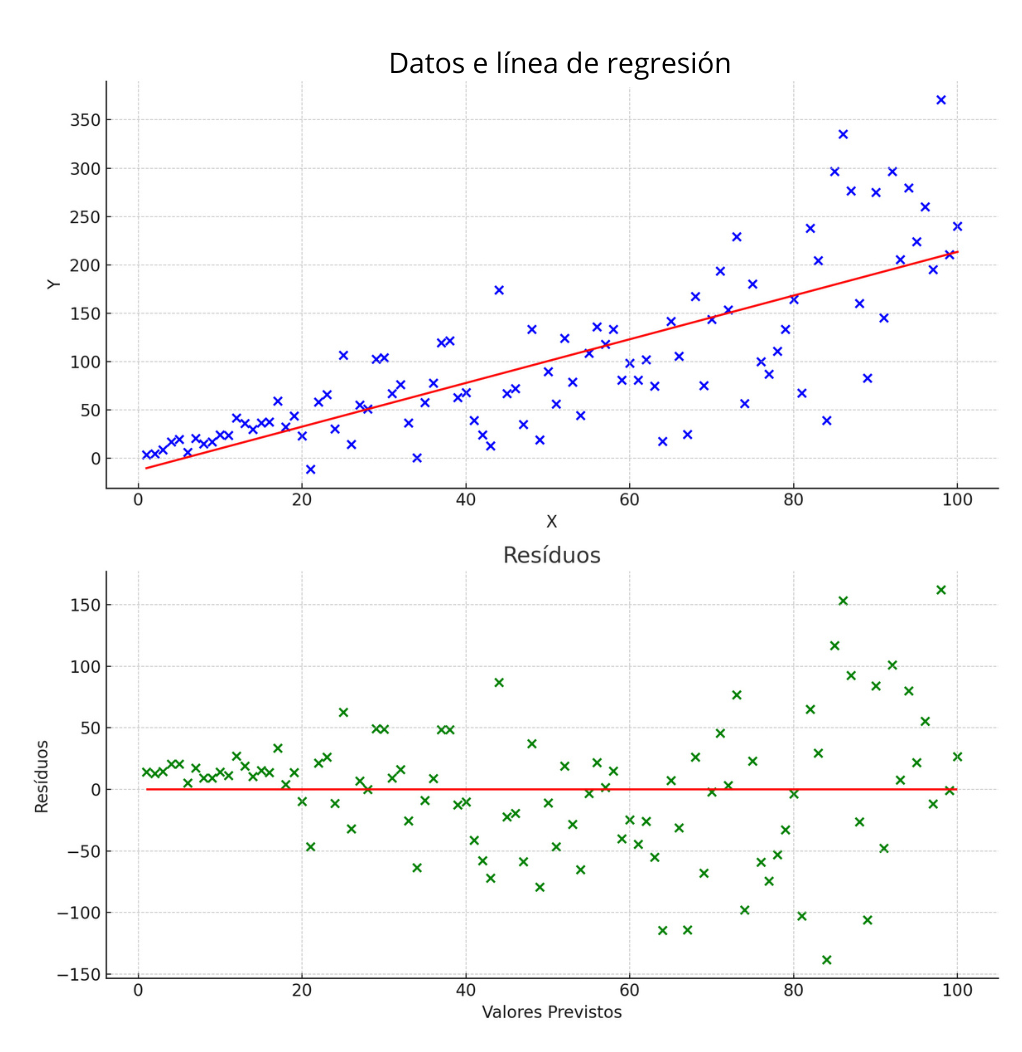
¿Por qué es un Problema la Heterocedasticidad?
La presencia de heterocedasticidad puede llevar a estimaciones de coeficientes ineficientes y a pruebas de hipótesis inválidas, comprometiendo la confiabilidad de las inferencias estadísticas. Aunque no afecta la imparcialidad o la consistencia de los estimadores de mínimos cuadrados ordinarios, impacta en la eficiencia de estos estimadores, haciéndolos menos confiables.

Identificando la Heterocedasticidad
Uno de los métodos más comunes para detectar la heterocedasticidad es a través del análisis visual de los residuos. Después de ajustar un modelo de regresión lineal, podemos graficar los residuos en función de los valores previstos. Si los residuos se dispersan de manera uniforme, sin formar patrones o embudos, el modelo probablemente presenta homocedasticidad. Por otro lado, si la dispersión de los residuos aumenta o disminuye con los valores previstos, esto indica heterocedasticidad.

¿Cómo Evaluar la Heterocedasticidad?
Además de un análisis visual de los residuos, existen varias pruebas estadísticas para evaluar formalmente la presencia de heterocedasticidad, como la prueba de White y la prueba de Breusch-Pagan. Estas pruebas ayudan a cuantificar si la varianza de los residuos está relacionada con los valores previstos, proporcionando una base más sólida para decidir si la heterocedasticidad es una preocupación significativa en el modelo.

Tratando la Heterocedasticidad
Si identificamos heterocedasticidad, se pueden adoptar varias enfoques para abordar el problema, como la transformación de variables (por ejemplo, logarítmica o raíz cuadrada) o el uso de técnicas de regresión robustas, que son menos sensibles a la varianza de los residuos.

Conclusión
Al comprender e identificar la heterocedasticidad, podemos tomar medidas apropiadas para garantizar que nuestros análisis de regresión lineal sean confiables y válidos. Este cuidado nos permite hacer inferencias más precisas y fundamentadas, esenciales para la toma de decisiones basadas en datos.

En esta clase, aprendiste a:
Comprender el concepto de multicolinealidad y cómo puede afectar la interpretación de los coeficientes en un modelo de regresión lineal;
Utilizar el Factor de Inflación de la Varianza (VIF) para cuantificar e identificar problemas de multicolinealidad entre variables explicativas;
Crear e interpretar gráficos de dispersión comparando los valores predichos por el modelo con los valores reales, identificando limitaciones del modelo;
Analizar los residuos del modelo para verificar la presencia de homocedasticidad, es decir, si la varianza de los residuos es constante;
Analizar las limitaciones del modelo, especialmente en la fijación de precios de propiedades más caras, y discutir la importancia de explorar nuevas variables explicativas.